In [1]:
# Use Frank2D_PROD to run the simulated version of Frank2D in Frank1D.

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

from frank.geometry import SourceGeometry
from frank.io import load_uvtable
from frank.radial_fitters import FrankFitter, FourierBesselFitter
from frank.utilities import UVDataBinner
from frank.constants import deg_to_rad

In [3]:
import pymoo

In [4]:
rad_to_arcsec = 3600 * 180 / np.pi

AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc':18.6, 'pa':169 , 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout':0.518*2, 'disk_name': 'HD143006'}

data = Elias27

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum_gridded_N200.txt"


# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
r_out = data['rout']

# Frank Parameters
N = 50
 # load data
u, v, Re, Im, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Im*1j

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)

NSTEP 41
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


[      0.     27428.83   54857.66   82286.49  109715.3   137144.2
  164573.    192001.8   219430.6   246859.5   274288.3   301717.1
  329146.    356574.8   384003.6   411432.5   438861.3   466290.1
  493719.    521147.8   548576.6   576005.4   603434.3   630863.1
  658291.9   685720.8   713149.6   740578.4   768007.3   795436.1
  822864.9   850293.7   877722.6   905151.4   932580.2   960009.1
  987437.9  1014867.   1042296.   1069724.   1097153.  ]


[-1.82289944e-05 -1.82289944e-05 -1.82289944e-05 ...  1.74998346e-05
  1.74998346e-05  1.74998346e-05]


[-1.82289944e-05 -1.74998346e-05 -1.67706749e-05 ...  1.60415151e-05
  1.67706749e-05  1.74998346e-05]




/Users/mariajmelladot/Desktop/Frank2D/2_Frank2D_PROD/frankenstein2D/frank/statistical_models.py:280: RuntimeWarning: divide by zero encountered in log
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)
/Users/mariajmelladot/Desktop/Frank2D/2_Frank2D_PROD/frankenstein2D/frank/statistical_models.py:280: RuntimeWarning: invalid value encountered in scalar multiply
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)


....................................NOT OPTIMIZING.................................. 
                 --------------> m, c, log_l -2 100000000.0 100000
Wendland kernel
--- 0.014058884233236313 minutes to calculate S---
--- 0.04865026846528053 minutes to calculate S_real---


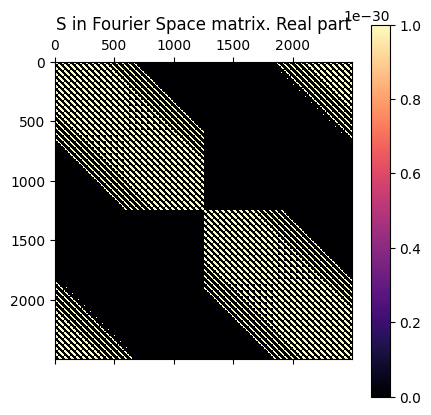

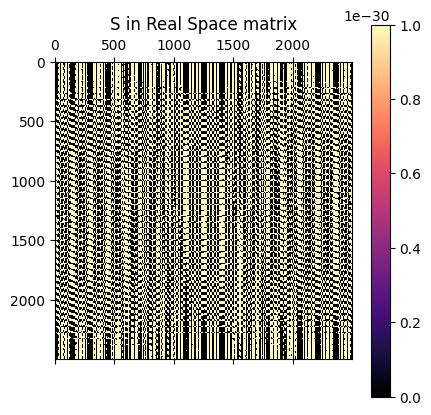

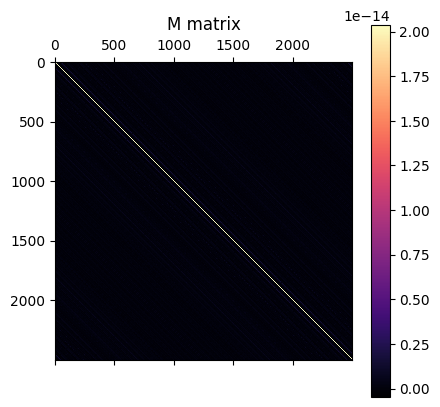

--- 0.005040716379880905 minutes calculate mu---
Is the result correct?:  True


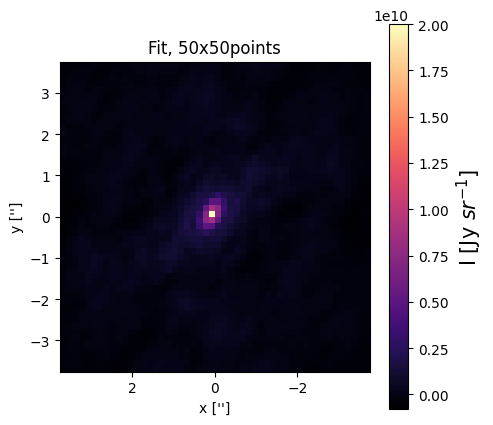

--- 0.09824587032198906 minutes to fit---
--- %s minutes --- 1.2117486437161764  or  72.70491862297058  seconds.


In [5]:
import time
start_time = time.time()
FF = FourierBesselFitter(r_out, N, geom)
sol = FF.fit(u, v, Vis, Weights)
total_time = time.time() - start_time
print("--- %s minutes ---", total_time/60, " or ", total_time, " seconds.")

In [6]:
sol._fit._DFT.Yn

array([-1.82289944e-05, -1.74998346e-05, -1.67706749e-05, ...,
        1.60415151e-05,  1.67706749e-05,  1.74998346e-05])

In [7]:
FF._sol._fit.plot_stats_optimization()

AttributeError: 'GaussianModel' object has no attribute '_loglikelihoods'

In [ ]:
len(sol.mean) # we corroborate the desire output has 25x25 points.

In [ ]:
FF._GaussianModel.plot_stats_optimization()

In [ ]:
I = sol.mean.real

In [ ]:
I_reshape = I.reshape(N, N)

In [ ]:
r_out_rad = r_out

In [ ]:
import matplotlib.colors as colors
x_f1d = FF._DFT.Xn*rad_to_arcsec
y_f1d = FF._DFT.Yn*rad_to_arcsec

fig, ax = plt.subplots(figsize=(5, 5))
norm = colors.PowerNorm(gamma=0.45)
plot = ax.pcolormesh(x_f1d.reshape(N, N), y_f1d.reshape(N, N), I_reshape, cmap="magma", norm=norm)
cmap = plt.colorbar(plot)
plt.gca().invert_xaxis()
cmap.set_label(r'I [Jy $sr^{-1}$]', size = 15)
ax.set_title(r'$N^{2}$ points, with N = ' + str(N))
ax.set_xlabel("x ['']")
ax.set_ylabel("y ['']")
plt.gca().set_aspect(1)  
plt.show()

In [ ]:
u_f1d = FF._DFT.Un
v_f1d = FF._DFT.Vn

fig, ax = plt.subplots(figsize=(5, 5))
plot = ax.pcolormesh(np.fft.fftshift(u_f1d.reshape(N, N))/1e6,
                     np.fft.fftshift(v_f1d.reshape(N, N))/1e6,
                     np.log(np.fft.fftshift(np.abs(np.fft.ifft2(I_reshape)))), cmap="magma")
cmap = plt.colorbar(plot)
cmap.set_label(r'I [Jy $sr^{-1}$]', size = 15)
ax.set_title(r'$N^{2}$ points, with N = ' + str(N))
ax.set_xlabel(r'u [1e6 $\lambda$]')
ax.set_ylabel(r'v [1e6 $\lambda$]')
plt.gca().set_aspect(1)  
plt.show()

In [ ]:
from scipy.stats import binned_statistic


def get_vis_profile_binned(u, v, Vis, Weights, n_bins = 300, weighted = False):
    q = np.hypot(u, v)
    
    Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*Weights, 'sum', bins = n_bins)
        Weights_binned, bin_edges, _ = binned_statistic(q, Weights, 'sum', bins = n_bins)
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned

In [ ]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u, v)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)

plt.figure(figsize=(14,5))

# Raw visibilities -------------------------------------------------------------------
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

#frank1d
n_bins = N
vis_fit_1d = sol.predict(u_f1d, v_f1d)
baselines_centers, vis_fit = get_vis_profile_binned(u_f1d, v_f1d, vis_fit_1d, Weights, n_bins = n_bins, weighted = False)
plt.plot(baselines_centers, np.abs(vis_fit), color = "blue", ls ='--', label = r'fit')

binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(0.5e-4, 1)
plt.xlim(1e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Model}$ of Frank2D simulated in Frank1D with N = ' + str(N))
plt.legend(fontsize= 10)
plt.show()


## Review the deprojected case

In [ ]:
# deproject
inc_rad = inc*deg_to_rad
pa_rad = pa*deg_to_rad

cos_t = np.cos(pa_rad)
sin_t = np.sin(pa_rad)

u_ = u * cos_t - v * sin_t
v_d = u * sin_t + v * cos_t
u_d = u_ * np.cos(inc_rad)

In [ ]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines_d = np.hypot(u_d, v_d)         
grid = np.logspace(np.log10(min(baselines_d.min(), baselines_d[0])),
                           np.log10(max(baselines_d.max(), baselines_d[-1])),
                           10**4)

plt.figure(figsize=(14,5))

# Raw visibilities -------------------------------------------------------------------
binned_vis = UVDataBinner(baselines_d, Vis, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines_d, Vis, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))
#frank1d
n_bins = 400
vis_fit_1d_d = sol.predict_deprojected(u_d, v_d)

baselines_centers_d, vis_fit_d = get_vis_profile_binned(u, v, vis_fit_d_shift, Weights, n_bins = n_bins)
plt.plot(baselines_centers_d, np.abs(vis_fit_d)/np.cos(inc_rad), color = "blue", ls ='--', label = r'frank1d')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(0.5e-4, 1)
plt.xlim(1e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ deprojected with ' + str(n_bins) + ' regular bins, Frank2D N = ' + str(N))
plt.legend(fontsize= 10)
plt.show()
